In [1]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells
from functools import partial
import numpy as np

PDK.activate()

## MMI 2X2 (VÉRTICES)

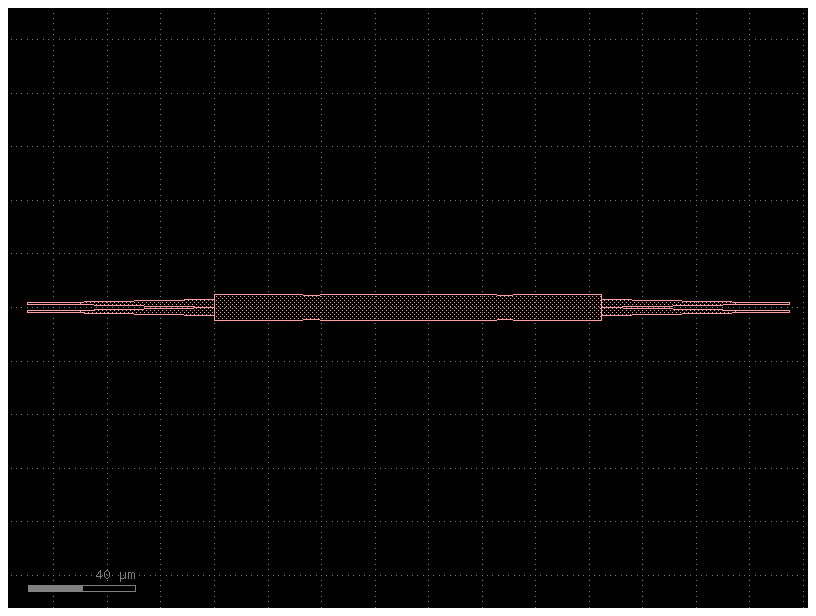

In [2]:
test  = cells.b_symmetric_mmi()
test.plot()

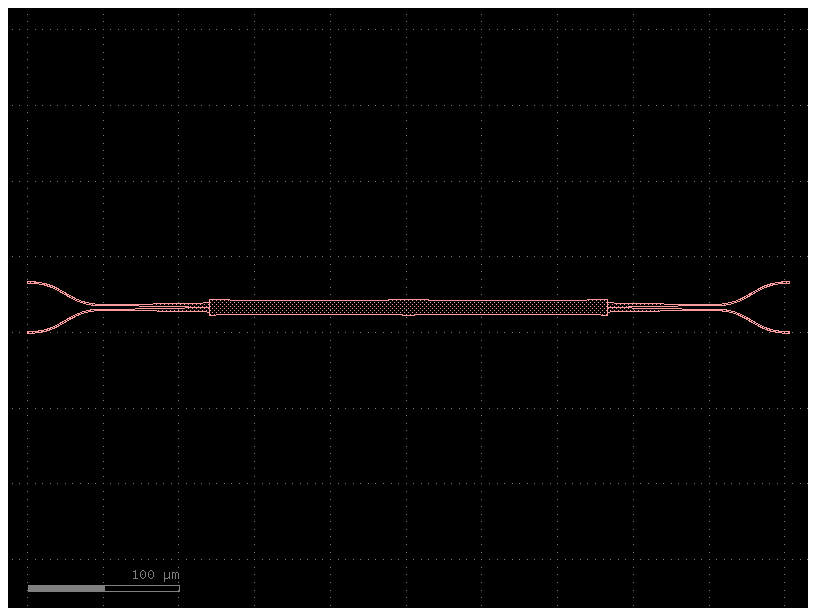

In [2]:
mmi95 = cells.mmi_2x2_bends()
mmi95.plot()

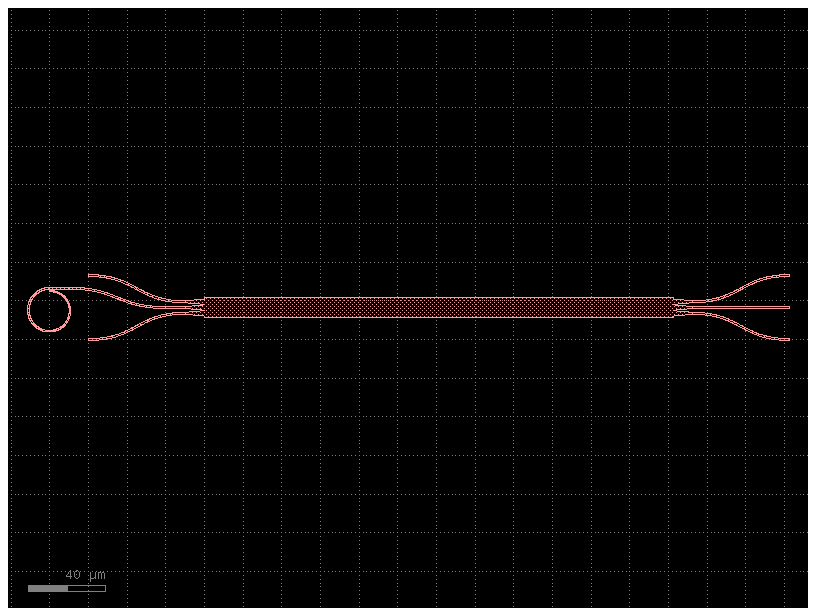

In [2]:
mmi33 = cells.mmi_3x3_test()
mmi33.plot()


2026-06-08 18:08:59.377 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/3208593984.oas'


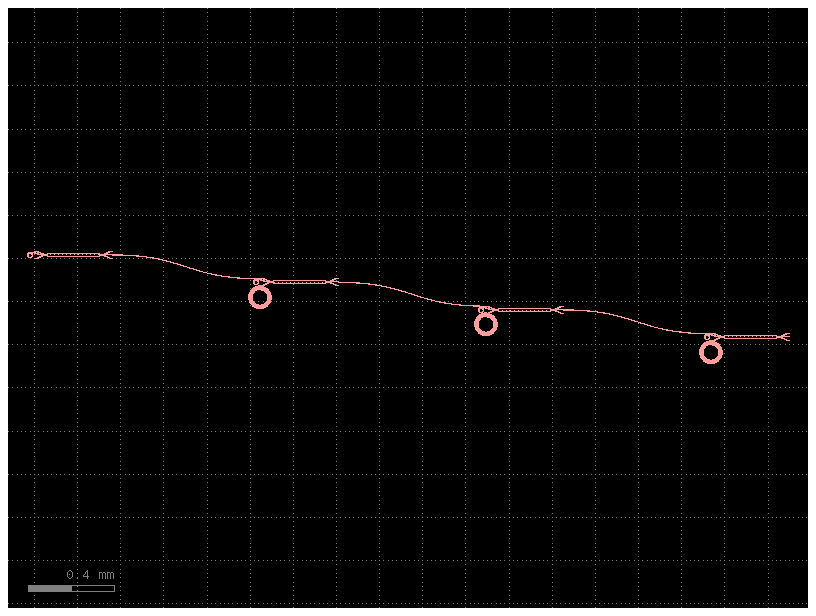

In [4]:
casc_A  = cells.mmi_ts(mmi33, 4500, 500, invert = True ,add_terminators=True)
casc_A.plot()
casc_A.show()

## MMI TEST STRUCTURES 2X2

2026-06-08 15:35:55.621 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/maria_romero/TFG/build/oas/1007440263.oas'


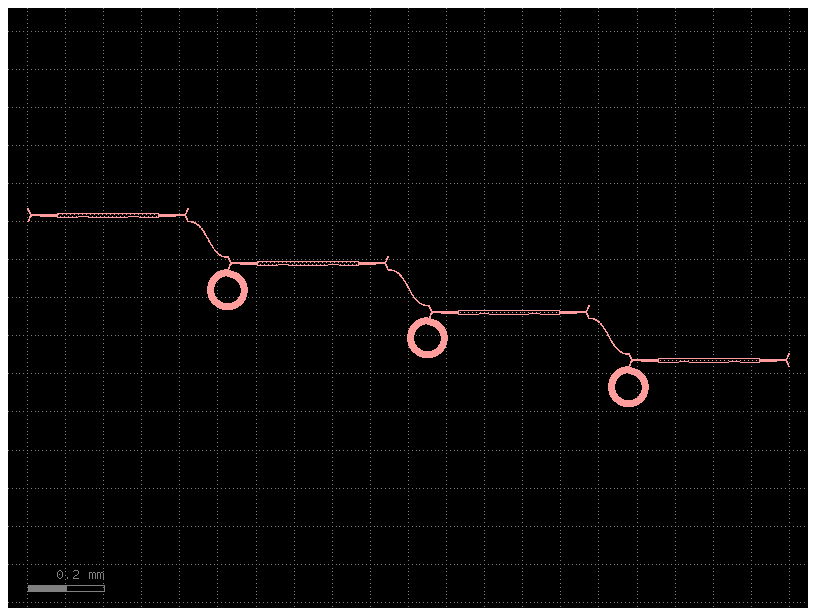

In [13]:
casc_A  = cells.mmi_ts(mmi95, 3000, 500, invert = True ,add_terminators=True)
casc_A.plot()
casc_A.show()

2026-06-08 15:42:24.462 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/2218000718.oas'


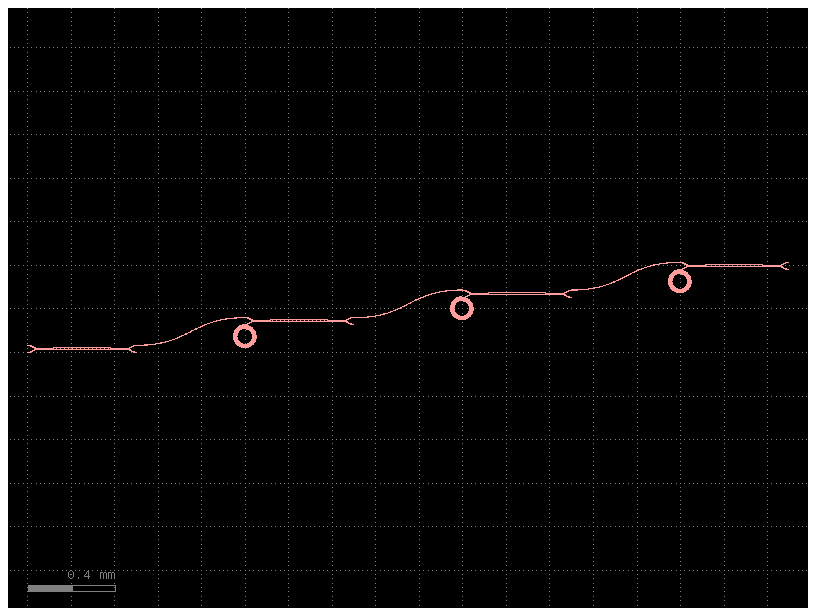

In [7]:
casc_B  = cells.mmi_ts(mmi95, 4500, 500,  add_terminators=True)
casc_B.plot()
casc_B.show()

## WAVLENGTH TRACKER NUEVO

Defining spiral length for delay: 124726.66735519293
Spiral length set to: 2120.00732421875
Spiral length 124726.64600000001
3000.007
2026-06-08 15:35:55.906 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/maria_romero/TFG/build/oas/2246057780.oas'


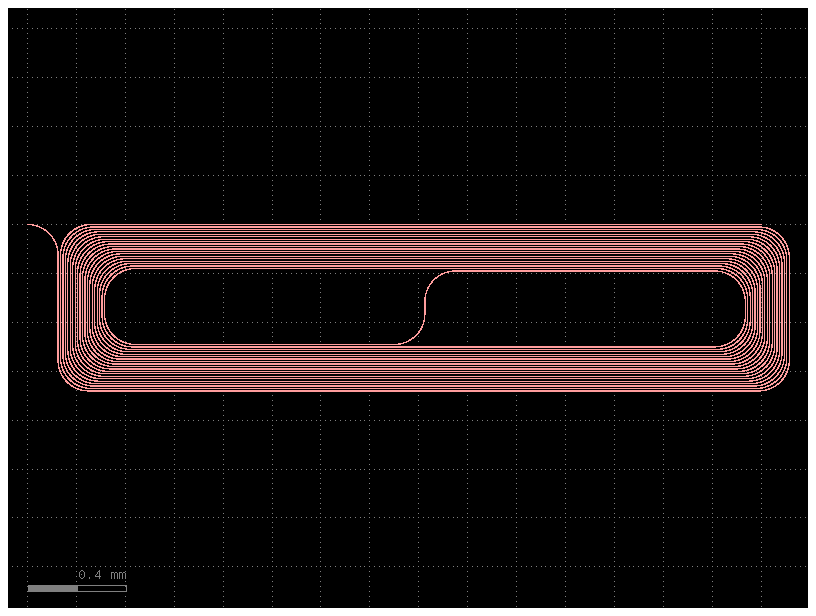

In [15]:
rad = 125
N_spr = 18
dy_spr = 50.46

L = 3000
AL = 121726.66735519293

target_length =  L +AL # in microns 
#target_length = 56032.624

dx_length_spiral = cells.define_spiral_length(delay_length=target_length,
                                        N_spr=N_spr, #N_spr: order-number of loops (0,1,...)
                                        radius=rad, 
                                        d_SPR=10, #d_SPR: waveguide separation
                                        dy_SPR=dy_spr,#dy_SPR: spiral straight extent in y
                                        )

spiral = cells.spiral_upv(
        radius=rad,
        N_spr=N_spr,
        d_SPR = 10,
        dy_SPR = dy_spr,
        dx_SPR = dx_length_spiral,
        layer="strip",
        )
print('Spiral length', spiral.info["length"])
h = spiral.ports["o2"].dx - spiral.ports["o1"].dx
spiral.plot()
spiral.show()
print(h)

2026-06-08 15:35:56.074 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/maria_romero/TFG/build/oas/404089563.oas'


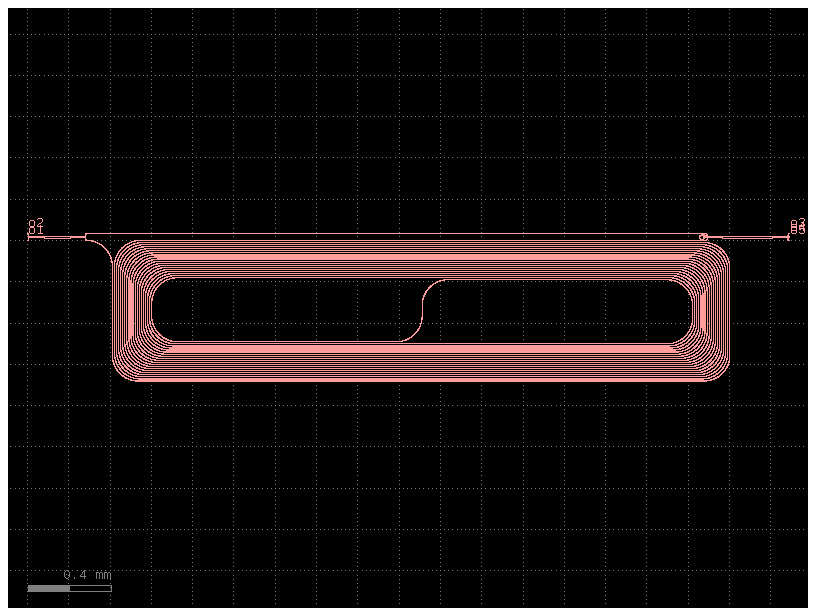

In [16]:
from upvfab.sin300.cband.tech import LAYER, TECH



test = cells.wvl_tracker_with_term()
test.draw_ports()
test.plot()
test.show()

3668.7793


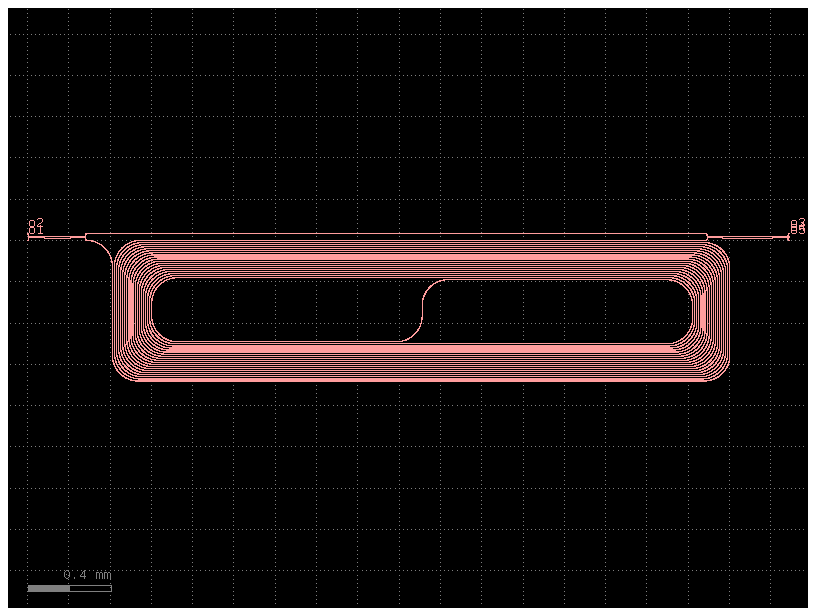

In [17]:
test = cells.wvl_tracker()
length = test.info["total_length_device"]
test.draw_ports()
test.plot()
#test.show()
print(length)

## CASCADAS MMI 3X3

2026-06-08 19:14:07.326 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/3638969829.oas'


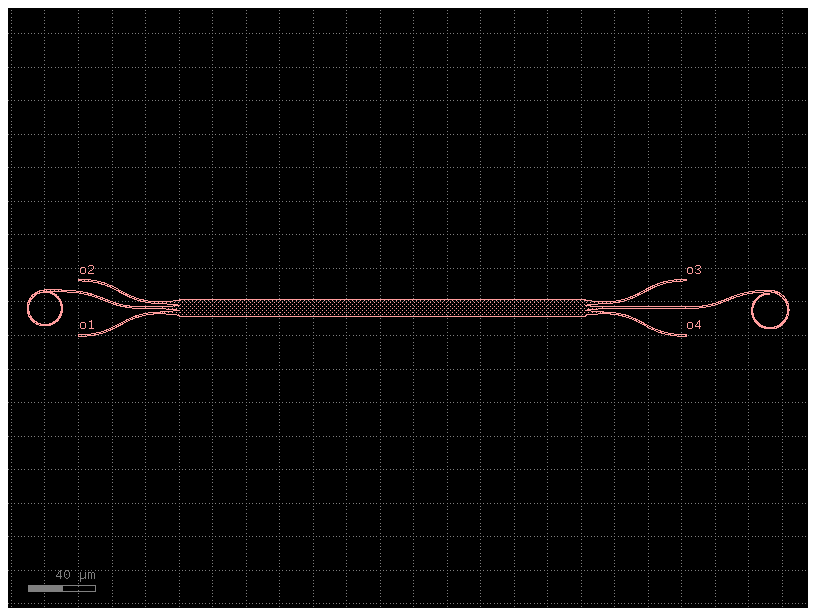

In [9]:
def dummy_2x2(index: float = 21):
    c = gf.Component()
    width = 1
    mmi33 = c << cells.mmi_3x3_test()
    term = cells.terminator(number_of_loops=4, min_bend_radius=35, width_tip = 0.6, separation = 3)
    term_middle = cells.terminator(number_of_loops=1, min_bend_radius=10, width_tip = 0.6, separation = 1.5)

    if index == 21 or index == 12:
        t_aux = c << term
        t_aux.mirror_x()
        t_aux.connect(port = 'o1', other = mmi33.ports['o5'])

        c.add_port(name = "o1", port = mmi33.ports["o1"], port_type = "optical")
        c.add_port(name = "o2", port = mmi33.ports["o2"], port_type = "optical")
        c.add_port(name = "o3", port = mmi33.ports["o3"], port_type = "optical")
        c.add_port(name = "o4", port = mmi33.ports["o4"], port_type = "optical")

    elif index == 31 or index == 13: 
        t_aux = c << term_middle
        t_aux.mirror_x()

        b = c << cells.bend_s(size = [50, 10], cross_section = "strip", width = width, allow_min_radius_violation = True)
        b.dmove((mmi33.ports['o4'].dx, mmi33.ports['o4'].dy ))
        t_aux.connect(port = 'o1', other = b.ports['o2'])

        c.add_port(name = "o1", port = mmi33.ports["o1"], port_type = "optical")
        c.add_port(name = "o2", port = mmi33.ports["o2"], port_type = "optical")
        c.add_port(name = "o3", port = mmi33.ports["o3"], port_type = "optical")
        c.add_port(name = "o4", port = mmi33.ports["o5"], port_type = "optical")
        

    
   
    return c

test = dummy_2x2(31)
test.draw_ports()
test.plot()
test.show()

2026-06-08 19:14:39.656 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/maria_romero/TFG/build/oas/3489047658.oas'


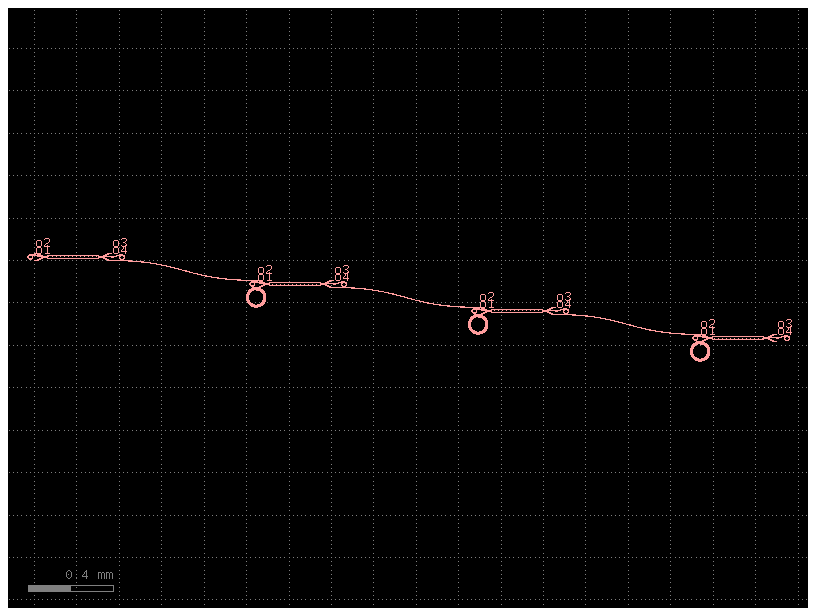

In [11]:
casc_A  = cells.mmi_ts(test, 4500, 500, invert = True ,add_terminators=True)
casc_A.plot()
casc_A.show()

# CHIP

2026-06-08 17:14:47.194 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


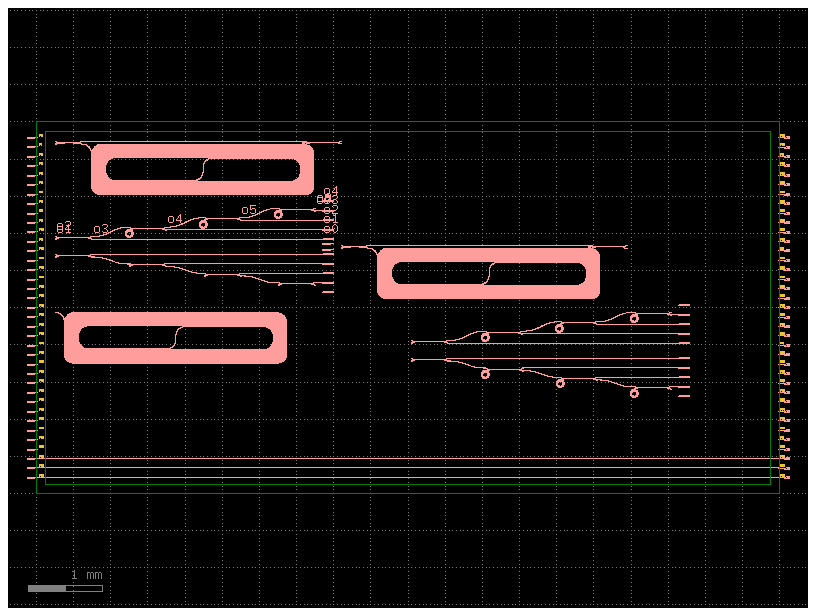

In [11]:
chip = gf.Component()
altura_cto = 713.5
altura_casc = 505
border = 125
grat_dx = 142.73
cto = cells.wvl_tracker_with_term()
length = cto.info["total_length_device"]

die = chip << cells.die_with_gratings(ngratings=37, grating_pitch = 127, edge_to_grating_distance= -125)
dist_grat_dy = die.ports['o74'].dy - die.ports['o73'].dy
dist_grat_dx = np.abs(die.ports['o74'].dx - die.ports['o1'].dx)

cto_1 = chip << cells.wvl_tracker_with_term()
cto_2 = chip << cells.wvl_tracker_with_term()
casc_A_1  = chip << cells.mmi_ts(mmi95, 4500, 500, invert = True ,add_terminators=False)
pitch_casc = casc_A_1.ports['o3'].dy - casc_A_1.ports['o4'].dy
casc_B_1  = chip << cells.mmi_ts(mmi95, 4500, 500,  add_terminators=True)
spiral_1 = chip << cells.spiral_upv(radius = 125, N_spr = 18 , d_SPR =10 , dx_SPR= 2120.00732421875, dy_SPR = 50.46, layer = "strip")
casc_A_2  = chip << cells.mmi_ts(mmi95, 4500, 500, invert = True ,add_terminators=True)
casc_B_2  = chip << cells.mmi_ts(mmi95, 4500, 500,  add_terminators=True)
wvg = gf.components.straight(dist_grat_dx)
bottom_wvg = chip << gf.components.array(component = wvg, columns = 1, rows = 3, row_pitch = dist_grat_dy)
gca = gf.c.grating_coupler_array(n=5, pitch=pitch_casc, with_loopback=False, grating_coupler= 'grating_coupler_rectangular')
gca_cto = gf.c.grating_coupler_array(n=2, pitch=80, with_loopback=False, grating_coupler= 'grating_coupler_rectangular')
gca_cB_1 = chip << gca
gca_cA_1 = chip << gca
gca_cB_2 = chip << gca
gca_cA_2 = chip << gca
gca_cto_2_in = chip << gca_cto


#posiciones

cto_1.dmove((250, 4700))
casc_B_1.dmove((cto_1.ports['o1'].dx, cto_1.ports['o1'].dy - 2*altura_cto + 150))
casc_A_1.dmove((cto_1.ports['o1'].dx, cto_1.ports['o1'].dy - altura_cto - altura_casc -300))
gca_cB_1.rotate(90)
gca_cB_1.dmove((casc_B_1.ports['o7'].dx +100, casc_B_1.ports['o5'].dy))
gca_cto_2_in.rotate(-90)
gca_cto_2_in.dmove((casc_B_1.ports['o7'].dx + 100 + grat_dx, casc_B_1.ports['o1'].dy + dist_grat_dy/2 -40 ))
cto_2.dmove((gca_cto_2_in.ports['o0'].dx +100 , gca_cto_2_in.ports['o0'].dy -60))
gca_cA_1.rotate(90)
gca_cA_1.dmove((casc_A_1.ports['o7'].dx +100, casc_A_1.ports['o5'].dy))

spiral_1.dmove((cto_1.ports['o1'].dx, cto_2.ports['o1'].dy - altura_cto - 150))
casc_B_2.dmove((cto_2.ports['o1'].dx + 950, cto_2.ports['o1'].dy - 2*altura_cto + 150))
casc_A_2.dmove((cto_2.ports['o1'].dx + 950, cto_2.ports['o1'].dy - altura_cto - altura_casc -300))
gca_cB_2.rotate(90)
gca_cB_2.dmove((casc_B_2.ports['o7'].dx +100, casc_B_2.ports['o5'].dy))
gca_cA_2.rotate(90)
gca_cA_2.dmove((casc_A_2.ports['o7'].dx +100, casc_A_2.ports['o5'].dy))
bottom_wvg.dmove((die.ports['o72'].dx , die.ports['o72'].dy))

#conexiones

#cascada 1
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o3'], port2=gca_cB_1.ports['o0'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o4'], port2=gca_cB_1.ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o5'], port2=gca_cB_1.ports['o2'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o7'], port2=gca_cB_1.ports['o3'], cross_section="strip")
# gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o6'], port2=gca_cB_1.ports['o4'], cross_section="strip")

gf.routing.route_single_sbend(chip, port1=casc_A_1.ports['o3'], port2=gca_cA_1.ports['o4'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_1.ports['o4'], port2=gca_cA_1.ports['o3'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_1.ports['o5'], port2=gca_cA_1.ports['o2'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_1.ports['o7'], port2=gca_cA_1.ports['o1'], cross_section="strip")
# gf.routing.route_single_sbend(chip, port1=casc_A_1.ports['o6'], port2=gca_cA_1.ports['o0'], cross_section="strip")

#cascada 2

gf.routing.route_single_sbend(chip, port1=casc_B_2.ports['o3'], port2=gca_cB_2.ports['o0'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_2.ports['o4'], port2=gca_cB_2.ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_2.ports['o5'], port2=gca_cB_2.ports['o2'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_2.ports['o7'], port2=gca_cB_2.ports['o3'], cross_section="strip")
# gf.routing.route_single_sbend(chip, port1=casc_B_2.ports['o6'], port2=gca_cB_2.ports['o4'], cross_section="strip")

gf.routing.route_single_sbend(chip, port1=casc_A_2.ports['o3'], port2=gca_cA_2.ports['o4'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_2.ports['o4'], port2=gca_cA_2.ports['o3'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_2.ports['o5'], port2=gca_cA_2.ports['o2'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_2.ports['o7'], port2=gca_cA_2.ports['o1'], cross_section="strip")
# gf.routing.route_single_sbend(chip, port1=casc_A_2.ports['o6'], port2=gca_cA_2.ports['o0'], cross_section="strip")




#chip.add_ports(die)
chip.add_ports(casc_B_1)
chip.add_ports(gca_cB_1)
chip.draw_ports()
chip.plot()
chip.show()